In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (7).zip to archive (7) (1).zip


In [5]:
!unzip brain_tumor_dataset.zip

unzip:  cannot find or open brain_tumor_dataset.zip, brain_tumor_dataset.zip.zip or brain_tumor_dataset.zip.ZIP.


In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [7]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [8]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [10]:
history = model.fit(
train_data,
epochs=10,
validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6502 - loss: 0.6817 - val_accuracy: 0.7400 - val_loss: 0.5425
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 945ms/step - accuracy: 0.7635 - loss: 0.4913 - val_accuracy: 0.7600 - val_loss: 0.6862
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8030 - loss: 0.5233 - val_accuracy: 0.7400 - val_loss: 0.5328
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8030 - loss: 0.4520 - val_accuracy: 0.7200 - val_loss: 0.6081
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8128 - loss: 0.4156 - val_accuracy: 0.7600 - val_loss: 0.5300
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8424 - loss: 0.3816 - val_accuracy: 0.7400 - val_loss: 0.5566
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8424 - loss: 0.4106 - val_accuracy: 0.7800 - val_loss: 0.5022
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8867 - loss: 0.3262 - val_accuracy: 0.7600 - val_loss: 0.5159
Epoch 9/10
7

In [11]:
loss, acc = model.evaluate(val_data)

print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.8200 - loss: 0.4726
Validation Accuracy: 0.8199999928474426


In [15]:
img, label = next(val_data)

prediction = model.predict(img)

print("Predicted:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
Predicted: [0.97554165]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 637ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

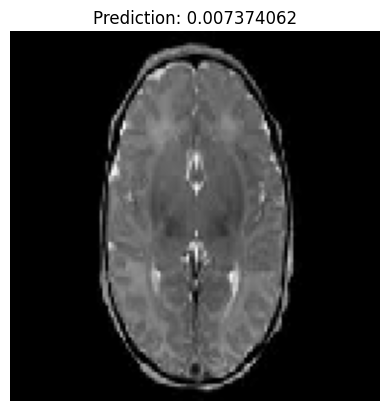

In [16]:
img, label = next(val_data)

prediction = model.predict(img)

plt.imshow(img[0])
plt.title("Prediction: " + str(prediction[0][0]))
plt.axis("off")